In [1]:
import config_paths_ipynb

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import glycowork.glycan_data.stats as glwstats

from ibd_biom_glycoda.config import DATASETS_DIR, FIGURE_DIR
from ibd_biom_glycoda.utils import seed_everything
from ibd_biom_glycoda.data.dataset import load_dataset_excel, prepare_ibd_dataset, generate_demographic_comparison
from ibd_biom_glycoda.data.transformations import apply_clr_transformation, residualize_coda
from ibd_biom_glycoda.analysis.similarity import generate_beta_diversity_pca_results, plot_beta_diversity_pca_panel
from ibd_biom_glycoda.plotting.style import rcparams_aga, generate_semantic_colors, create_figure_with_panels, save_figure_aga_compliant

# Seed everything
SEED = 42
seed_everything(SEED)
# Override glycowork RNG
glwstats.rng = np.random.default_rng(SEED)

PALETTE = 'okabe_ito'
rcparams_aga(palette=PALETTE)
DISEASE_COLORS, COHORT_COLORS,  *_ = generate_semantic_colors(palette=PALETTE, preview=False)

Notebook config loaded. Project root added: C:\Users\konst\GitProjects\ibd-biom-glycoda


# Import and prepare data

In [2]:
# Import data
fname = 'ibd_biom_prospective_dataset_baseline.xlsx'
df_ibd = load_dataset_excel(fname, data_dir=DATASETS_DIR)

# Prepare multi-class dataset
df_multi, coda_cols = prepare_ibd_dataset(df_ibd, binary=False)
print(f"\nValues counts for multi-class dataset:\n{df_multi['DISEASE'].value_counts()}")

# Print dataset summary shapes
print(f"Loaded dataset shape: {df_ibd.shape}")
print(f"Prepared dataset shape: {df_multi.shape}")

# Prepare binary dataset
df_binary = df_multi.copy()
df_binary['DISEASE'] = df_binary['DISEASE'].replace({'HC': 'Non-IBD', 'SC': 'Non-IBD', 'CD': 'IBD', 'UC': 'IBD'})
print(f"\nValues counts for binary dataset:\n{df_binary['DISEASE'].value_counts()}")

Dropped 0 low abundant GP columns: []
Retained 24 GP columns: ['GP1_FA1', 'GP2_A2', 'GP3_A2B', 'GP4_FA2', 'GP5_M5', 'GP6_FA2B', 'GP7_A2G1', 'GP8_FA2_6_G1', 'GP9_FA2_3_G1', 'GP10_FA2_6_BG1', 'GP11_FA2_3_BG1', 'GP12_A2G2', 'GP13_A2BG2', 'GP14_FA2G2', 'GP15_FA2BG2', 'GP16_FA2G1S1', 'GP17_A2G2S1', 'GP18_FA2G2S1', 'GP19_FA2BG2S1', 'GP20__', 'GP21_A2G2S2', 'GP22_A2BG2S2', 'GP23_FA2G2S2', 'GP24_FA2BG2S2']

Values counts for multi-class dataset:
DISEASE
HC    375
CD    362
SC    356
UC    274
Name: count, dtype: int64
Loaded dataset shape: (1449, 31)
Prepared dataset shape: (1367, 31)

Values counts for binary dataset:
DISEASE
Non-IBD    731
IBD        636
Name: count, dtype: int64


In [3]:
COVARIATES = ['Age', 'Sex']

DISEASE_ORDER_MULTI = ['HC', 'SC', 'CD', 'UC']
DISEASE_ORDER_BINARY = ['Non-IBD', 'IBD']
COHORT_ORDER = ['UK', 'US', 'IT', 'NL']

# Dataset description

In [4]:
generate_demographic_comparison(df=df_multi, 
                                by_disease=False,
                                binary=False, 
                                disease_order=DISEASE_ORDER_MULTI, 
                                cohort_order=COHORT_ORDER,
                                alpha=0.05,
                                show_pvalues=False)

Group,UK,US,IT,NL
n,406,472,307,182
"Age (median, IQR)",33.5 (26.0-48.5),38.0 (30.0-52.0),54.0 (38.0-64.0),47.0 (26.0-61.0)
"Females (n, %)",194 (47.8%),291 (61.7%),149 (48.5%),106 (58.2%)
"Group - HC (n, %)",88 (21.7%),36 (7.6%),187 (60.9%),64 (35.2%)
"Group - SC (n, %)",74 (18.2%),220 (46.6%),NaN,62 (34.1%)
"Group - CD (n, %)",112 (27.6%),152 (32.2%),64 (20.8%),34 (18.7%)
"Group - UC (n, %)",132 (32.5%),64 (13.6%),56 (18.2%),22 (12.1%)


# Clustering with beta-diversity using residualized CLR data

  Cohort  Dunn index  Mean silhouette width
0     UK       0.078                  0.064
1     US       0.074                  0.078
2     IT       0.099                  0.047
3     NL       0.128                  0.046
✓ CMYK TIFF created


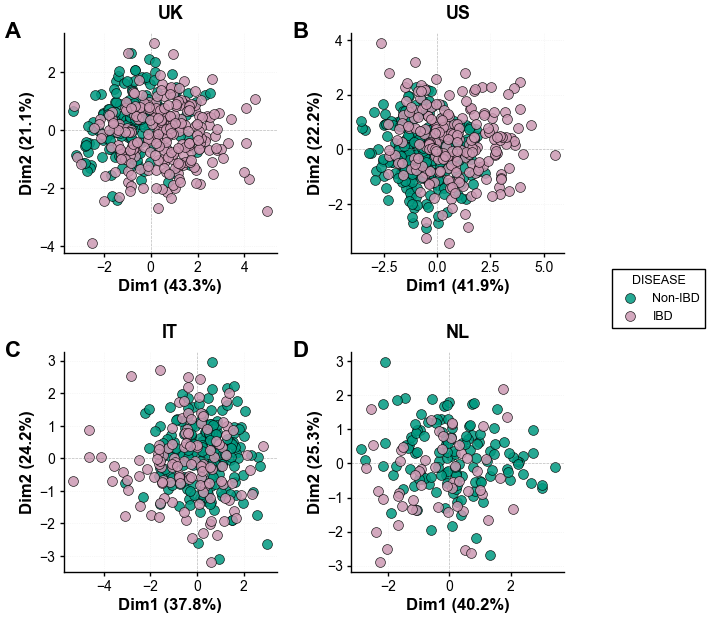

In [5]:
# Residualized CLR data for beta diversity PCA - binary
df_binary_clr_resid = df_binary.copy()
df_binary_clr_resid[coda_cols] = residualize_coda(
    apply_clr_transformation(
        df_binary[coda_cols],
        group1=df_binary.index.tolist(),
        group2=[],
        gamma=0.1,
        custom_scale=None,
        seed=SEED
    ),
    df_binary[COVARIATES],
    covariates=COVARIATES
)

cohort_pca_results_binary_resid = generate_beta_diversity_pca_results(df_binary_clr_resid, coda_cols, stratify_col='Cohort', cluster_col='DISEASE', cohort_order=COHORT_ORDER)
cohort_metrics_binary_resid = (pd.concat([metrics for (_, metrics) in cohort_pca_results_binary_resid.values()], ignore_index=True))
print(cohort_metrics_binary_resid[['Cohort', 'Dunn index', 'Mean silhouette width']])

# Create figure with panels
fig, axes = create_figure_with_panels(figsize=(7, 7), layout=(2, 2))
fig.subplots_adjust(wspace=0.35, hspace=0.45, right=0.84)

# Plot each panel
for ax, cohort in zip(axes, COHORT_ORDER):
    pca_df = cohort_pca_results_binary_resid[cohort][0]
    plot_beta_diversity_pca_panel(ax, pca_df, 'DISEASE', DISEASE_ORDER_BINARY, DISEASE_COLORS, title=cohort)

# Add shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title='DISEASE', 
          loc='center left', bbox_to_anchor=(0.9, 0.5))

_, _ = save_figure_aga_compliant(fig=fig, filename='figure 1', format='tiff', dpi=500, path=FIGURE_DIR)

  Cohort  Dunn index  Mean silhouette width
0     UK       0.078                 -0.033
1     US       0.074                 -0.042
2     IT       0.099                  0.019
3     NL       0.126                 -0.023
✓ CMYK TIFF created


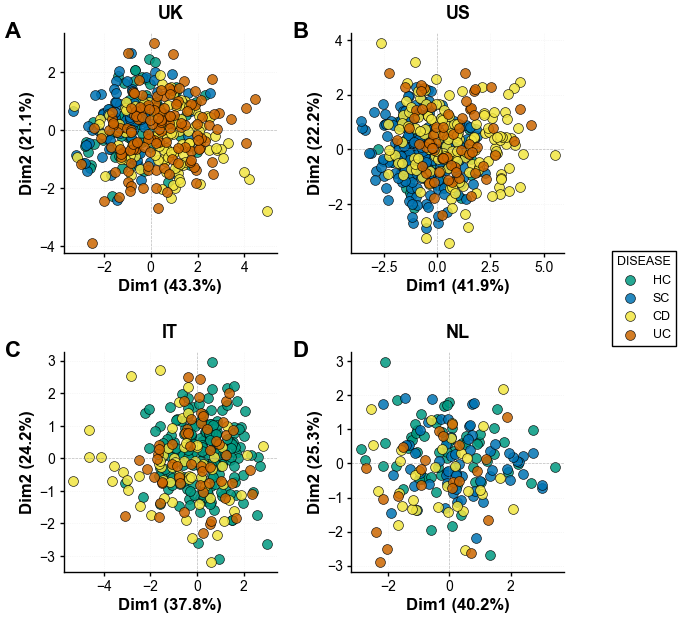

In [6]:
# Residualized CLR data for beta diversity PCA - multi-class
df_multi_clr_resid = df_multi.copy()
df_multi_clr_resid[coda_cols] = residualize_coda(
    apply_clr_transformation(
        df_multi[coda_cols],
        group1=df_multi.index.tolist(),
        group2=[],
        gamma=0.1,
        custom_scale=None,
        seed=SEED
    ),
    df_multi[COVARIATES],
    covariates=COVARIATES
)

cohort_pca_results = generate_beta_diversity_pca_results(df_multi_clr_resid, coda_cols, stratify_col='Cohort', cluster_col='DISEASE', cohort_order=COHORT_ORDER)
cohort_metrics = (pd.concat([metrics for (_, metrics) in cohort_pca_results.values()], ignore_index=True))
print(cohort_metrics[['Cohort', 'Dunn index', 'Mean silhouette width']])

# Create figure with panels
fig, axes = create_figure_with_panels(figsize=(7, 7), layout=(2, 2))
fig.subplots_adjust(wspace=0.35, hspace=0.45, right=0.84)

# Plot each panel
for ax, cohort in zip(axes, COHORT_ORDER):
    pca_df = cohort_pca_results[cohort][0]
    plot_beta_diversity_pca_panel(ax, pca_df, 'DISEASE', DISEASE_ORDER_MULTI, DISEASE_COLORS, title=cohort)

# Add shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title='DISEASE', 
          loc='center left', bbox_to_anchor=(0.9, 0.5))

_, _ = save_figure_aga_compliant(fig=fig, filename='figure S1', format='tiff', dpi=500, path=FIGURE_DIR)